   порог K  p успех сильного  p успех слабого
0       15          0.999998         0.988747
1       16          0.999961         0.956826
2       17          0.999400         0.867047
3       18          0.992931         0.676927
4       19          0.940101         0.391747
5       20          0.667608         0.121577


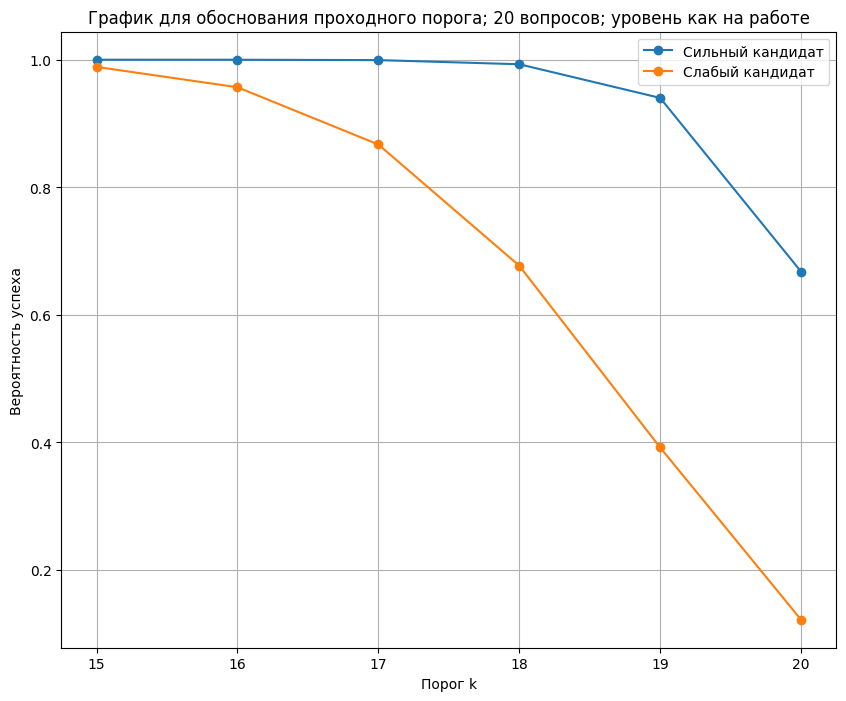

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
import numpy as np

n = 20 # кол-во вопросов
k = np.arange(15,n+1) # порог

#Данные из кейса
p_strong_normal, p_weak_normal = 0.98, 0.90
p_strong_easy,   p_weak_easy   = 0.99, 0.95
p_strong_hard,   p_weak_hard   = 0.70, 0.20

#Binom для показания порога 
probs_strong_normal = binom.sf(k-1, n, p_strong_normal)
probs_weak_normal = binom.sf(k-1, n, p_weak_normal)

df_normal = pd.DataFrame({
    'порог K': k,
    'p успех сильного': probs_strong_normal,
    'p успех слабого': probs_weak_normal
})

print(df_normal)

plt.figure(figsize=(10,8))
plt.plot(k, probs_strong_normal, marker='o', label='Сильный кандидат')
plt.plot(k, probs_weak_normal, marker='o', label='Слабый кандидат')
plt.title('График для обоснования проходного порога; 20 вопросов; уровень как на работе')
plt.xlabel('Порог k')
plt.ylabel('Вероятность успеха')
plt.grid(True)
plt.legend()
plt.show()

    кол-во вопросов  порог K  Вер-ть прохождения сильного, %  \
0                24       23                           91.74   
1                25       24                           91.14   
2                26       25                           90.52   
3                27       26                           89.89   
4                28       27                           89.25   
5                29       28                           88.60   
6                30       29                           87.95   
7                31       30                           87.28   
8                32       31                           86.60   
9                33       32                           85.92   
10               34       33                           85.23   

    Вер-ть исключения слабого, %  
0                          70.75  
1                          72.88  
2                          74.87  
3                          76.74  
4                          78.48  
5                    

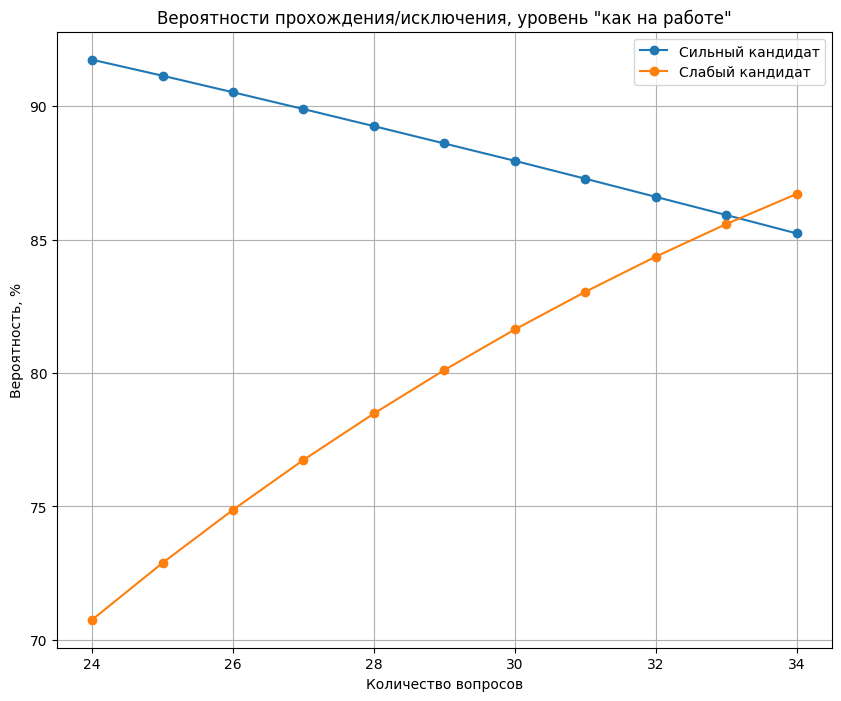

In [2]:
n = np.arange(10,35,1)
variants = []

for questions in n:

    k = np.arange(0,questions+1)
    probs_strong = 1 - binom.cdf(k-1, questions, p_strong_normal)
    probs_weak = binom.cdf(k-1, questions, p_weak_normal)

    mask = (probs_strong >=0.8) & (probs_weak >=0.7)

    if mask.any():
        k_optimal = k[mask][0]
        variants.append({
            'кол-во вопросов': questions,
            'порог K': k_optimal,
            'Вер-ть прохождения сильного, %': round(probs_strong[k_optimal] * 100, 2),
            'Вер-ть исключения слабого, %': round(probs_weak[k_optimal] * 100, 2)
        })

df = pd.DataFrame(variants)
print(df)

plt.figure(figsize=(10,8))
plt.plot(df['кол-во вопросов'], df['Вер-ть прохождения сильного, %'], marker='o', label='Сильный кандидат')
plt.plot(df['кол-во вопросов'], df['Вер-ть исключения слабого, %'], marker='o', label='Слабый кандидат')
plt.title('Вероятности прохождения/исключения, уровень "как на работе"')
plt.xlabel('Количество вопросов')
plt.ylabel('Вероятность, %')
plt.grid(True)
plt.legend()
plt.show()

    кол-во вопросов  порог K  Вер-ть прохождения сильного, %  \
0                49       48                           91.36   
1                50       49                           91.06   
2                51       50                           90.75   
3                52       51                           90.44   
4                53       52                           90.13   
5                54       53                           89.82   
6                55       54                           89.50   
7                56       55                           89.18   
8                57       56                           88.86   
9                58       57                           88.53   
10               59       58                           88.21   

    Вер-ть исключения слабого, %  
0                          71.01  
1                          72.06  
2                          73.07  
3                          74.05  
4                          75.00  
5                    

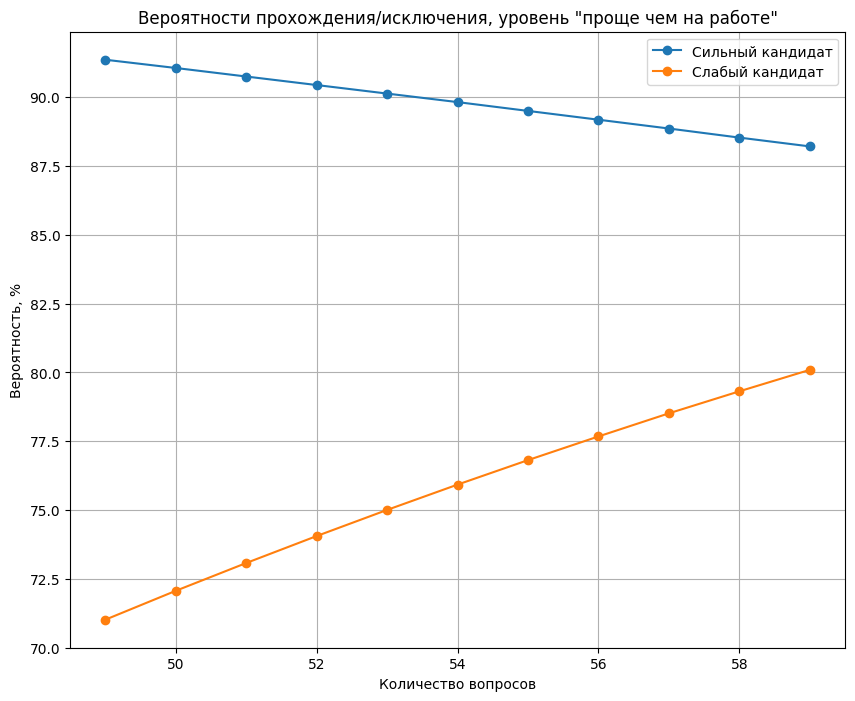

In [3]:
n = np.arange(10,60,1)
variants = []

for questions in n:

    k = np.arange(0,questions+1)
    probs_strong = 1 - binom.cdf(k-1, questions, p_strong_easy)
    probs_weak = binom.cdf(k-1, questions, p_weak_easy)

    mask = (probs_strong >=0.8) & (probs_weak >=0.7)

    if mask.any():
        k_optimal = k[mask][0]
        variants.append({
            'кол-во вопросов': questions,
            'порог K': k_optimal,
            'Вер-ть прохождения сильного, %': round(probs_strong[k_optimal] * 100, 2),
            'Вер-ть исключения слабого, %': round(probs_weak[k_optimal] * 100, 2)
        })

df = pd.DataFrame(variants)
print(df)

plt.figure(figsize=(10,8))
plt.plot(df['кол-во вопросов'], df['Вер-ть прохождения сильного, %'], marker='o', label='Сильный кандидат')
plt.plot(df['кол-во вопросов'], df['Вер-ть исключения слабого, %'], marker='o', label='Слабый кандидат')
plt.title('Вероятности прохождения/исключения, уровень "проще чем на работе"')
plt.xlabel('Количество вопросов')
plt.ylabel('Вероятность, %')
plt.grid(True)
plt.legend()
plt.show()

   кол-во вопросов  порог K  Вер-ть прохождения сильного, %  \
0                4        2                           91.63   
1                5        2                           96.92   
2                6        3                           92.95   
3                7        3                           97.12   
4                8        3                           98.87   
5                9        3                           99.57   

   Вер-ть исключения слабого, %  
0                         81.92  
1                         73.73  
2                         90.11  
3                         85.20  
4                         79.69  
5                         73.82  


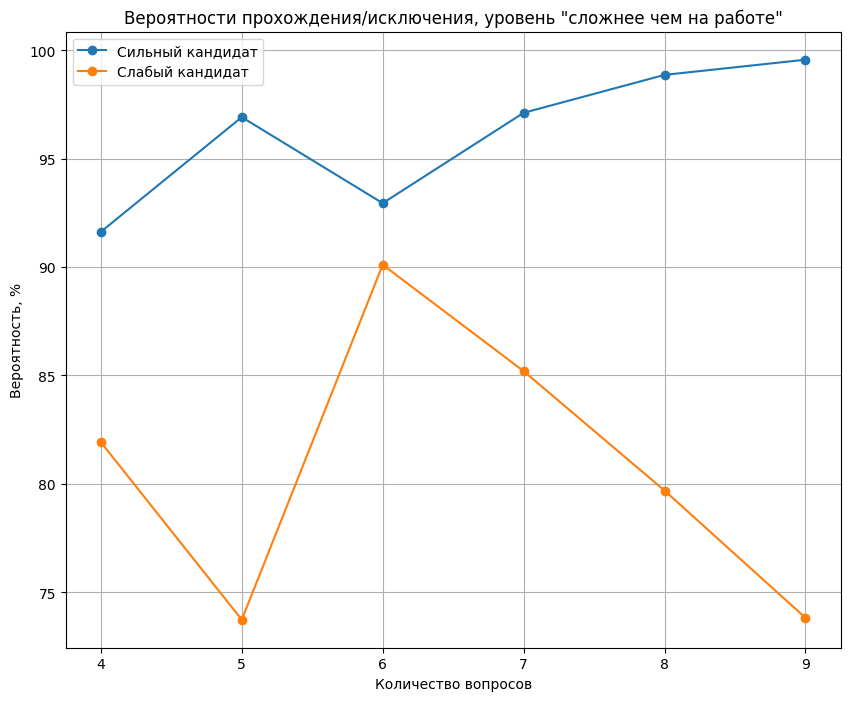

In [4]:
n = np.arange(1,10,1)
variants = []

for questions in n:

    k = np.arange(0,questions+1)
    probs_strong = 1 - binom.cdf(k-1, questions, p_strong_hard)
    probs_weak = binom.cdf(k-1, questions, p_weak_hard)

    mask = (probs_strong >=0.8) & (probs_weak >=0.7)

    if mask.any():
        k_optimal = k[mask][0]
        variants.append({
            'кол-во вопросов': questions,
            'порог K': k_optimal,
            'Вер-ть прохождения сильного, %': round(probs_strong[k_optimal] * 100, 2),
            'Вер-ть исключения слабого, %': round(probs_weak[k_optimal] * 100, 2)
        })

df = pd.DataFrame(variants)
print(df)

plt.figure(figsize=(10,8))
plt.plot(df['кол-во вопросов'], df['Вер-ть прохождения сильного, %'], marker='o', label='Сильный кандидат')
plt.plot(df['кол-во вопросов'], df['Вер-ть исключения слабого, %'], marker='o', label='Слабый кандидат')
plt.title('Вероятности прохождения/исключения, уровень "сложнее чем на работе"')
plt.xlabel('Количество вопросов')
plt.ylabel('Вероятность, %')
plt.grid(True)
plt.legend()
plt.show()